In [1]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2024)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
from utils import coords_2_strain_nn_vmap
from utils import train, coords_2_strain_nn
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, plotmesh_updated, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Generate data + pretraining

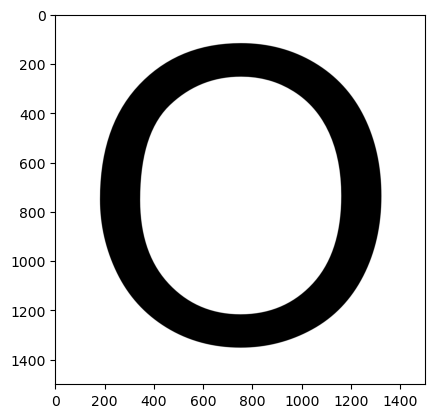

In [2]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 100, 100
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('/home/amir/inverse_prob/O.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])

In [3]:
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [4]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])


# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]
n_elem = Nx*Ny
u_hist_goh=[]
F_hist_goh_gt = []
P_hist_goh_gt = []
for lmb_max in lmb_hist:
    # dirichlet_bc_info = [
    #     [bottom,            top],
    #     [1,                 1 ],
    #     [zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max)]
    # ]
    # dirichlet_bc_info = [
    #     [left, right],
    #     [0, 0],
    #     [zero_dirichlet,lambda p: lmbx_max_dirichlet(p, lmb_max)]]
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    middle_displacements = []
    for element in mesh.cells:
       element_displacements = u[element,:]
       middle_displacements.append(np.mean(element_displacements, axis=0))
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    u_hist_goh.append(np.array(middle_displacements))
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh_gt.append(F)
    P_hist_goh_gt.append(P)
F_hist_goh_gt = np.array(F_hist_goh_gt)
P_hist_goh_gt = np.array(P_hist_goh_gt)
u_hist_goh = np.array(u_hist_goh)

[12-09 18:09:15][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[12-09 18:09:15][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[12-09 18:09:15][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[12-09 18:09:15][DEBUG] jax_fem: Done pre-computations, took 0.5293838977813721 [s]
[12-09 18:09:15][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[12-09 18:09:18][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[12-09 18:09:18][DEBUG] jax_fem: Start timing
[12-09 18:09:18][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[12-09 18:09:20][DEBUG] jax_fem: Function split_and_compute_cell took 1.6663 seconds
[12-09 18:09:20][DEBUG] jax_fem: Creating sparse matrix with scipy...
[12-09 18:09:21][DEBUG] jax_fem: Linear guess solve...
[12-09 18:09:21][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[12-09 18:09:21][DEBUG] jax_fem: PET

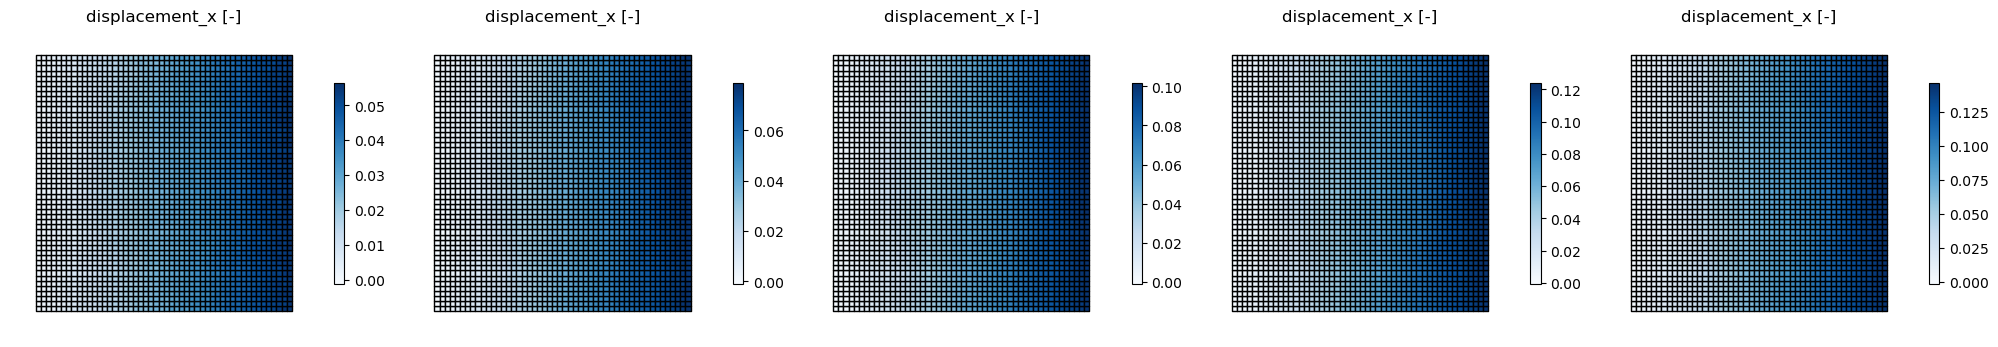

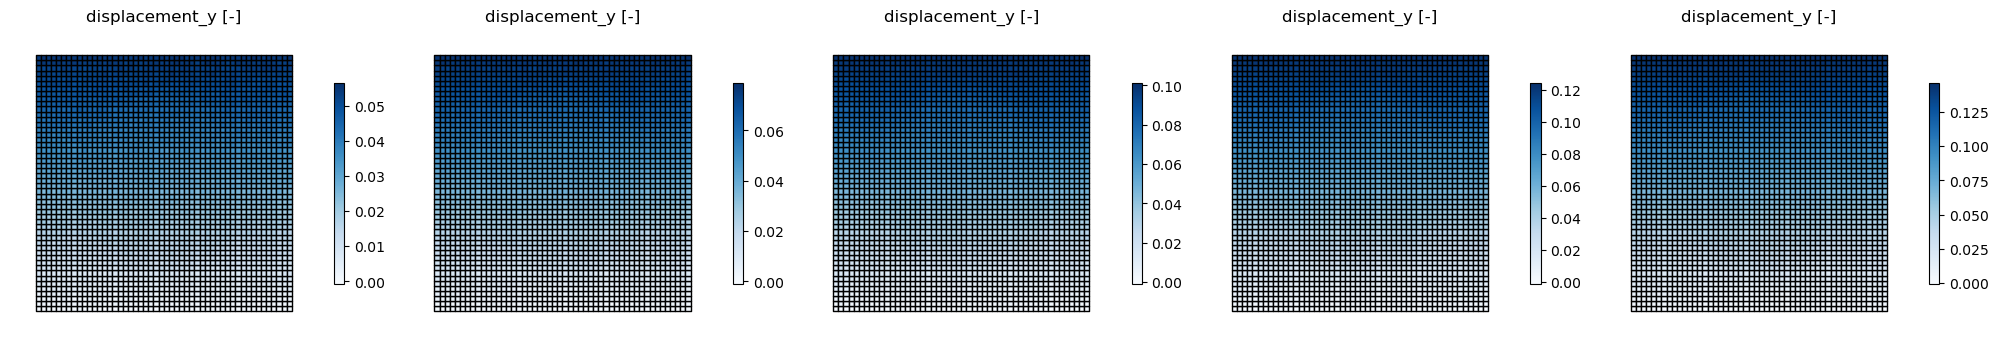

In [5]:
displacements = []
u_hist_noisy=[]
t_hist = np.arange(len(u_hist_goh))
lmb_hist_plot = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]

n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 

fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))

axes_x = axes_x.flatten()
axes_y = axes_y.flatten()

for idx, (lmb_i, t, u) in enumerate(zip(lmb_hist_plot, t_hist, u_hist_goh)):
    key = random.PRNGKey(int(t**3))
    noise = jax.random.normal(key, shape=u.shape)
    mu=0
    sigma=0.0007
    noise=mu + sigma * noise
    noise_scale = 1
    u_noisy = u + noise_scale * noise
    u_hist_noisy.append(u_noisy)
    u_noisy_x = u_noisy[:, [0]].flatten()
    u_noisy_y = u_noisy[:, [1]].flatten()

    ax_x = axes_x[idx]
    plotmesh(mesh.cells, mesh.points, u_noisy_x, title=f'displacement_x [-]', ax=ax_x)

    ax_y = axes_y[idx]
    plotmesh(mesh.cells, mesh.points, u_noisy_y, title=f'displacement_y [-]', ax=ax_y)

    displacements.append(np.array([t * np.ones(len(u)), u_noisy[:, 0], u_noisy[:, 1]]))

for i in range(n_plots, len(axes_x)):
    fig_x.delaxes(axes_x[i])
for i in range(n_plots, len(axes_y)):
    fig_y.delaxes(axes_y[i])

fig_x.tight_layout()
fig_y.tight_layout()

plt.show()
u_hist_noisy=np.array(u_hist_noisy)
displacements = np.hstack(displacements)


#### FDM calculation of the F based on displacement

In [6]:
### assuming we have a square domain where everything is symmetric wrt x and y
def richardson_derivative(Z, h):
    """Calculates the derivatives using finite difference and Richardson extrapolation for step size h."""
    Z_x = np.zeros_like(Z)
    Z_y = np.zeros_like(Z)
    rows, cols = Z.shape
    for i in range(rows):
        for j in range(cols):
            if i == 0:  
                Z_y[i, j] = (Z[i + 1, j] - Z[i, j]) / h
            elif i == rows - 1:  
                Z_y[i, j] = (Z[i, j] - Z[i - 1, j]) / h
            else:  
                dy_h = (Z[i + 1, j] - Z[i - 1, j]) / (2 * h)
                
        
                f_y_plus_h_half = (Z[i + 1, j] + Z[i, j]) / 2
                f_y_minus_h_half = (Z[i - 1, j] + Z[i, j]) / 2
                
                dy_h_over_2 = (f_y_plus_h_half - f_y_minus_h_half) / h

               
                # Z_y[i, j] = (4 * dy_h_over_2 - dy_h) / 3
                Z_y[i, j] = dy_h
            if j == 0: 
                Z_x[i, j] = (Z[i, j + 1] - Z[i, j]) / h
            elif j == cols - 1: 
                Z_x[i, j] = (Z[i, j] - Z[i, j - 1]) / h
            else:  
                dx_h = (Z[i, j + 1] - Z[i, j - 1]) / (2 * h)
                
                f_x_plus_h_half = (Z[i, j + 1] + Z[i, j]) / 2
                f_x_minus_h_half = (Z[i, j - 1] + Z[i, j]) / 2
                
                dx_h_over_2 = (f_x_plus_h_half - f_x_minus_h_half) / h

                #Z_x[i, j] = (4 * dx_h_over_2 - dx_h) / 3
                Z_x[i, j] = dx_h

    return Z_x,Z_y
X_grid=elem_X[:,0].reshape((Nx,Ny)).T
Y_grid=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
u_hist_for_derivative=[]
for ii in range(u_hist_goh.shape[0]):
        u1=u_hist_noisy[ii,:,:]
        ux_grid=np.zeros((Nx,Ny))
        uy_grid=np.zeros((Nx,Ny))
        id_mesh=0
        for i in range(Nx):
            for j in range(Ny):
                ux_grid[j,i]=u1[id_mesh,0]
                uy_grid[j,i]=u1[id_mesh,1]
                id_mesh+=1
        u_hist_for_derivative.append([X_grid,Y_grid,ux_grid,uy_grid])
F_num_calculated=np.zeros_like(F_hist_goh_gt)
for ii in range(len(u_hist_for_derivative)):
           a,b,ux_grid,uy_grid=u_hist_for_derivative[ii]
           #print(ux_grid)
           uxx,uxy=richardson_derivative(ux_grid,1/Nx)
           #print('derivative')
           #print(uxx)
           uyx,uyy=richardson_derivative(uy_grid,1/Nx)
           id_mesh=0
           for i in range(uxx.shape[0]):
                for j in range(uxx.shape[1]):
                     F_num_calculated[ii,id_mesh, :,:]=np.array([[uxx[j,i]+1,uxy[j,i]],[uyx[j,i],uyy[j,i]+1]])
                     id_mesh+=1
#print(uy_grid.T[::-1,:])
# plt.scatter(elem_X[:,0], elem_X[:,1])
# a=elem_X[:,0].reshape((Nx,Ny)).T
# b=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
# print(a)
# print(b)


#### calculation of the error with respect to F_gt without noise

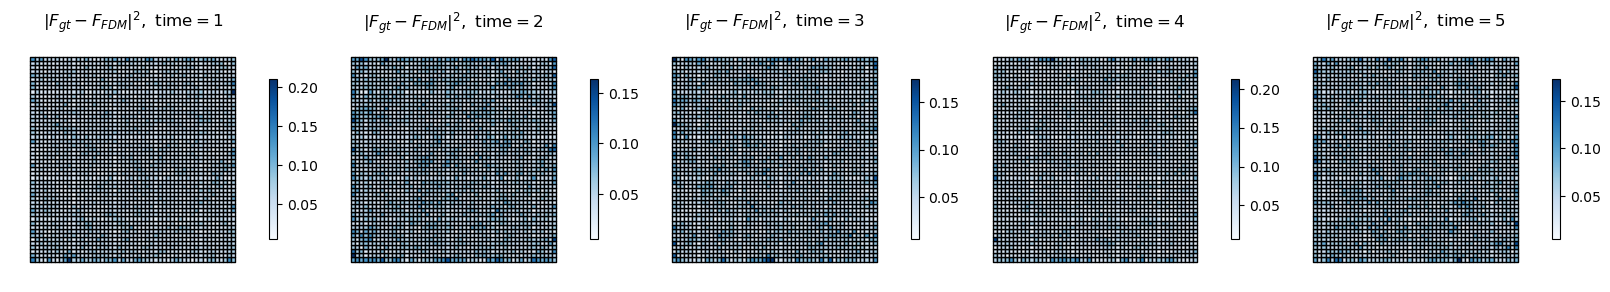

In [7]:
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
id_for_range=0
for idx, (t, F_gt, F) in enumerate(zip(t_hist, F_hist_goh_gt, F_num_calculated)):
    if id_for_range==n_cols:
        id_for_range=0
    ax_x = axes_x[idx]
    F_error = np.linalg.norm(F_gt-F, axis=(1, 2))
    label = fr'$|F_{{gt}}-F_{{FDM}}|^2,\ \text{{time}}={t+1}$'
    plotmesh(mesh.cells, mesh.points, F_error,title=label, ax=ax_x)
    #F_noisy=F+noise
    #strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1
#F_hist_goh.shape

#### plot based on $F_{FDM}$

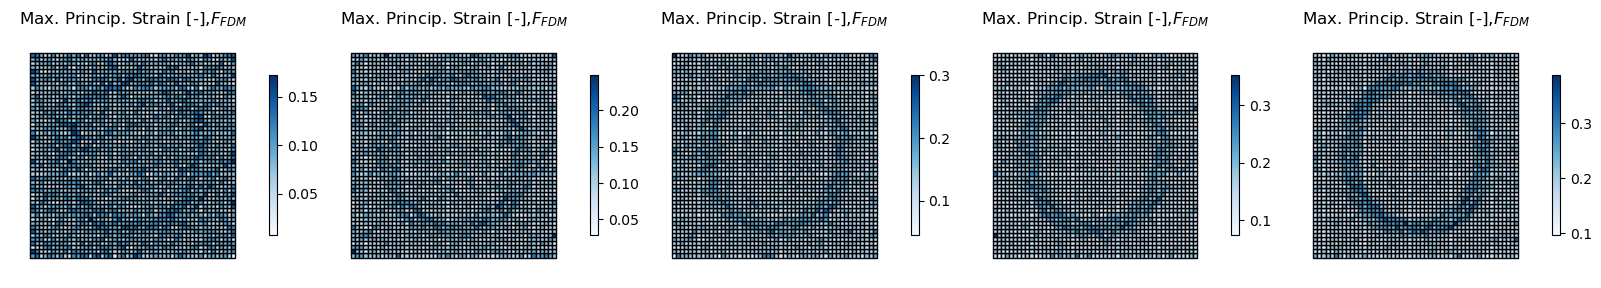

In [8]:
fig, axes = plt.subplots(1,5,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
F_hist_goh = []
for t, F, P, ax in zip(t_hist, F_num_calculated, P_hist_goh_gt, axes):
    F_noisy=F
    F_hist_goh.append(F_noisy)

    E = E_fun(F_noisy)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title=r'Max. Princip. Strain [-],$F_{FDM}$', ax=ax); 
    #F_noisy=F+noise
    strains.append(np.array([t*np.ones(len(F)), F_noisy[:,0,0], F_noisy[:,0,1], F_noisy[:,1,0], F_noisy[:,1,1]]))
strains = np.hstack(strains)

### interpolation of the $F_{FDM}$

In [9]:
# instead of using a 2D spline, use a NN to get the strain field for a given (x,y)
def loss_coords_2_strain(params, X, key):
    params_fwd=[ff_params, params]
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params_fwd)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 100 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = nn_params

opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X, elem_X, elem_X, elem_X,elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

it 1000, train loss = 2.560599e-04
it 2000, train loss = 2.470736e-04
it 3000, train loss = 2.014438e-04
it 4000, train loss = 2.269237e-04
it 5000, train loss = 2.318570e-04
it 6000, train loss = 2.040800e-04
it 7000, train loss = 2.364165e-04
it 8000, train loss = 2.192479e-04
it 9000, train loss = 2.251147e-04
it 10000, train loss = 1.890317e-04
it 11000, train loss = 2.059884e-04
it 12000, train loss = 2.052243e-04
it 13000, train loss = 2.054069e-04
it 14000, train loss = 2.137389e-04
it 15000, train loss = 2.018673e-04
it 16000, train loss = 2.184010e-04
it 17000, train loss = 2.022719e-04
it 18000, train loss = 2.289634e-04
it 19000, train loss = 2.077918e-04
it 20000, train loss = 2.037820e-04
it 21000, train loss = 1.935189e-04
it 22000, train loss = 2.184845e-04
it 23000, train loss = 2.030364e-04
it 24000, train loss = 2.152436e-04
it 25000, train loss = 2.017624e-04
it 26000, train loss = 1.990741e-04
it 27000, train loss = 1.997570e-04
it 28000, train loss = 1.999005e-04
i

#### 

#### plot for NN interpolation of $F_{FDM}$

In [10]:
coord_2_strain_params=[ff_params, coord_2_strain_params]

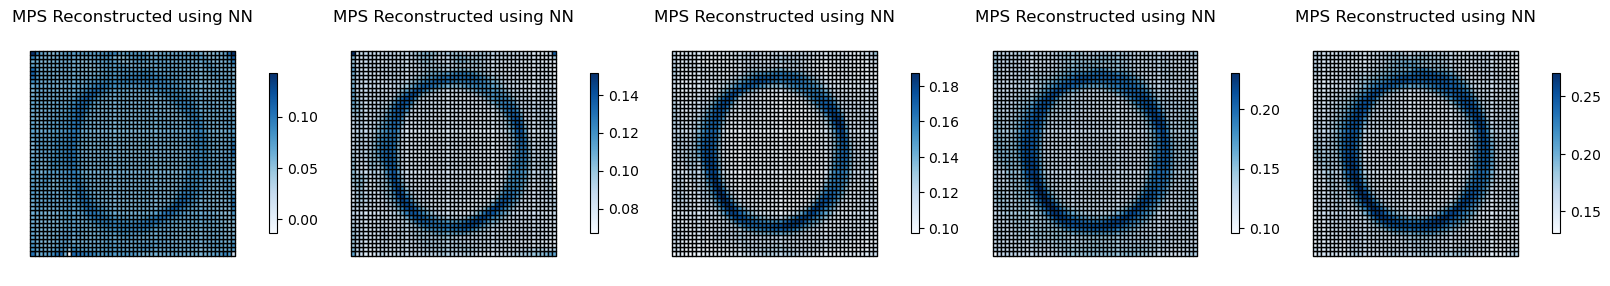

In [11]:
fig, axes = plt.subplots(1,5,figsize=(20,4))
for t in t_hist:
    ax = axes[t]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=ax); 

#### calculation of the error of $F_{NN}$ wrt $F_{gt}$

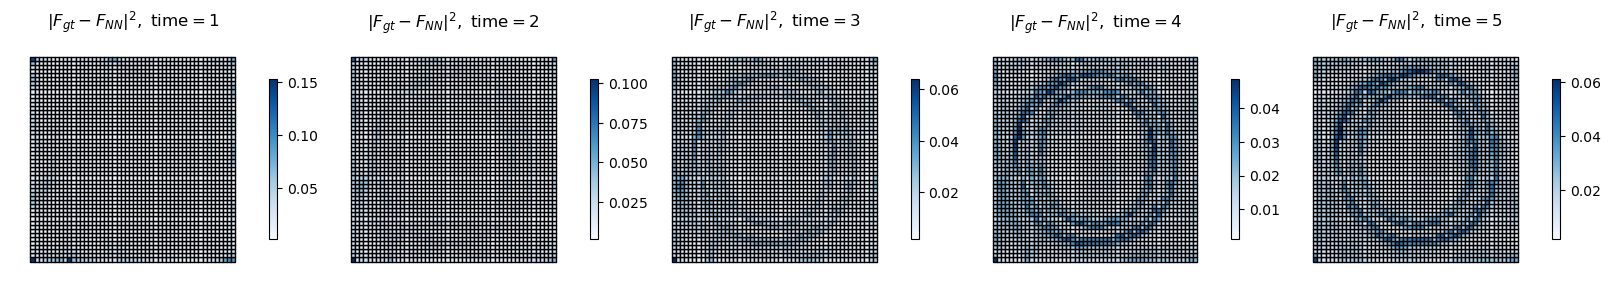

In [12]:
n_plots = len(u_hist_goh)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
id_for_range=0
F_hist_goh = []
for idx, (t,F_gt) in enumerate(zip(t_hist,F_hist_goh_gt)):
    if id_for_range==n_cols:
        id_for_range=0
    ax_x = axes_x[idx]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F_NN = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_hist_goh.append(F_NN)
    F_error = np.linalg.norm(F_gt-F_NN, axis=(1, 2))
    label = fr'$|F_{{gt}}-F_{{NN}}|^2,\ \text{{time}}={t+1}$'
    plotmesh(mesh.cells, mesh.points, F_error,title=label, ax=ax_x)
    #F_noisy=F+noise
    #strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
    id_for_range+=1
F_hist_goh=np.array(F_hist_goh)

In [13]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh_gt[:,rgt_bd_elems,0,0], axis=1)
lft_bd_frc = np.sum(P_hist_goh_gt[:,lft_bd_elems,0,0], axis=1)
top_bd_frc = np.sum(P_hist_goh_gt[:,top_bd_elems,1,1], axis=1)
bot_bd_frc = np.sum(P_hist_goh_gt[:,bot_bd_elems,1,1], axis=1)
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

#### saving  and reading info for interolated and ground-truth data  

In [14]:
with open('params_for_cluster_ring_noisy_p0007_copy_biaxial_test_prob_FDM_key2024.npy' ,'wb') as f:
    pickle.dump([coord_2_strain_params, mesh.points,elem_X, Force_x, Force_y, strains,u_hist_goh,
                 bd_X, lmb_hist, P_hist_goh_gt,F_hist_goh, t_hist,len(rgt_bd_elems),len(top_bd_elems )], f)

In [16]:

with open('params_for_cluster_ring_noisy_p0007_copy_biaxial_test_prob_FDM_key2024.npy', 'rb') as f:
    coord_2_strain_params, mesh.points,elem_X, Force_x, Force_y, strains,u_hist_goh,\
                 bd_X, lmb_hist, P_hist_goh_gt,F_hist_goh, t_hist,len_rgt_bd_elems,len_top_bd_elems  = pickle.load(f)

#### pretraining NODE's params to regenerate average stress

In [17]:
# Homogenize the strains
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T

n_neurons = 4
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

it 1000, train loss = 2.986685e-02
it 2000, train loss = 1.109165e-02
it 3000, train loss = 4.156686e-03
it 4000, train loss = 5.890850e-05
it 5000, train loss = 1.210227e-05
it 6000, train loss = 1.202489e-05
it 7000, train loss = 1.190047e-05
it 8000, train loss = 1.170380e-05
it 9000, train loss = 1.140328e-05
it 10000, train loss = 1.119383e-05
it 11000, train loss = 1.043054e-05
it 12000, train loss = 9.710398e-06
it 13000, train loss = 2.769572e-06
it 14000, train loss = 2.188508e-06
it 15000, train loss = 2.152352e-06
it 16000, train loss = 2.135853e-06
it 17000, train loss = 2.118903e-06
it 18000, train loss = 2.100827e-06
it 19000, train loss = 2.082397e-06
it 20000, train loss = 2.064555e-06


In [18]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.39153 0.52634 0.65125 0.76631 0.87347] [0.37784 0.50607 0.62371 0.73087 0.82941]
pr P_xx & P_yy:  [0.39055 0.52731 0.65218 0.76478 0.87397] [0.37721 0.50695 0.62437 0.72919 0.83014]


#### pretraining the hyper network to generate params of NODE, which is homogeneous at this point

In [19]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_strain_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 40
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,40,40,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 5000, print_freq=1000)

it 1000, train loss = 1.693463e-04
it 2000, train loss = 4.612662e-05
it 3000, train loss = 1.862910e-05
it 4000, train loss = 8.835589e-06
it 5000, train loss = 4.552913e-06


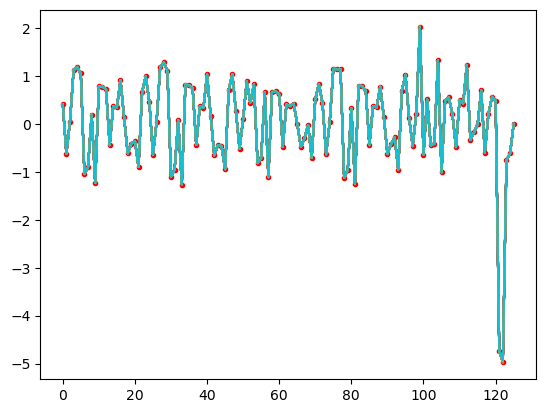

In [20]:
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

#### second pretraining of the hyper network to acount for non-homogeneous deformation gradient

In [23]:
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y

In [24]:
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):

    P_pred = get_P_vmap(XYt_colloc[:,0],XYt_colloc[:,1], XYt_colloc[:,2], Lambda_params, coord_2_strain_params, NODE_w_unravel)
    P_xx = P_xx_mean[jnp.array(XYt_colloc[:,2], int)]
    P_yy = P_yy_mean[jnp.array(XYt_colloc[:,2], int)]

    loss_P = jnp.mean((P_pred[0] - P_xx)**2 + (P_pred[3] - P_yy)**2)
    # loss_F = 0.0
    
    return loss_P

lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 50000, print_freq=100, batch_size=3000)

it 1, val loss = 1.242658e-01
it 101, val loss = 2.411631e-03
it 201, val loss = 1.468816e-03
it 301, val loss = 1.189549e-03


KeyboardInterrupt: 

#### saving data of hyper network after second pretraining to plot the results

In [20]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/biaxial_noisy_p0007_copy_biaxial_tests_displacement_second_pretraining.pickle', 'wb') as f:
    pickle.dump([Lambda_params,val_loss, metrics], f)

#### saving all data before the main training of the inverse problem

In [21]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/biaxial_noisy_p0005_biaxial_tests_displacement_pre.npy', 'wb') as f:
    pickle.dump([coord_2_displacement_params,coord_2_strain_params, node_params, Lambda_params,mesh.points, elem_X, Force_x, Force_y, strains,
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist], f)

#### training of the inverse problem based on interploation on displacement

In [22]:
def get_P_from_dis(X, Y, t, Lambda_params, coord_2_displacement_params, model):
    

    du1_dx1 =grad(lambda X_,Y_,t_:coords_2_strain_nn_vmap(jnp.hstack((X_, Y_, t_)), coord_2_displacement_params)[0], argnums=0)
    du1_dx2 =grad(lambda X_,Y_,t_:coords_2_strain_nn_vmap(jnp.hstack((X_, Y_, t_)), coord_2_displacement_params)[0], argnums=1)
    du2_dx1 =grad(lambda X_,Y_,t_:coords_2_strain_nn_vmap(jnp.hstack((X_, Y_, t_)), coord_2_displacement_params)[1], argnums=0)
    du2_dx2 =grad(lambda X_,Y_,t_:coords_2_strain_nn_vmap(jnp.hstack((X_, Y_, t_)), coord_2_displacement_params)[1], argnums=1)
    
    u_xx=du1_dx1(X,Y,t)
    u_xy=du1_dx2(X,Y,t)
    u_yx=du2_dx1(X,Y,t)
    u_yy=du2_dx2(X,Y,t)
    #F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[u_xx, u_xy],[u_yx, u_yy]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_Pxx = lambda X, Y, t, a, b, c: get_P_from_dis(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P_from_dis(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P_from_dis(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P_from_dis(X, Y, t, a, b, c)[3]
get_P_vmap = vmap(get_P_from_dis, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))
Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

In [23]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/biaxial_noisy_p0005_biaxial_tests_displacement_pre.npy', 'rb') as f:
   [coord_2_displacement_params,coord_2_strain_params, node_params, Lambda_params,mesh_points, elem_X, Force_x, Force_y, strains,
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist]=pickle.load(f)

#### here is the main training

In [24]:
# Train
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
a1 = 1000
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        Fx = Force_x[jnp.array(t, int)]
        Fy = Force_y[jnp.array(t, int)]
        return None, a2*((F_rgt-Fx)**2 + (F_top-Fy)**2 + (F_lft-Fx)**2 + (F_bot-Fy)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

lr = .3e-4
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 40000, print_freq=1000, batch_size=1000)

with open('/home/amir/inverse_prob/params_for_noise_tuning/ring_biaxial_noisy_p0005_prob_displacement_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist], f)

2024-10-16 21:07:09.666013: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-10-16 21:10:14.759592: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5m5.093679233s

********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


it 1, val loss = 6.267091e-01


2024-10-16 21:16:40.867480: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5m2.634558715s

********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


it 1001, val loss = 2.903899e-01
it 2001, val loss = 1.601605e-01
it 3001, val loss = 1.922357e-01
it 4001, val loss = 2.000780e-01
it 5001, val loss = 1.768666e-01
it 6001, val loss = 1.464286e-01
it 7001, val loss = 2.198909e-01
it 8001, val loss = 1.120571e-01
it 9001, val loss = 1.338226e-01
it 10001, val loss = 9.357307e-02
it 11001, val loss = 2.544829e-01
it 12001, val loss = 1.917800e-01
it 13001, val loss = 1.557724e-01
it 14001, val loss = 1.054914e-01
it 15001, val loss = 3.260344e-01
it 16001, val loss = 1.888000e-01
it 17001, val loss = 2.134807e-01
it 18001, val loss = 1.436913e-01
it 19001, val loss = 2.487608e-01
it 20001, val loss = 4.474258e-01
it 21001, val loss = 2.006804e-01
it 22001, val loss = 2.842440e-01
it 23001, val loss = 1.723567e-01
it 24001, val loss = 1.837217e-01
it 25001, val loss = 1.565821e-01
it 26001, val loss = 1.820542e-01
it 27001, val loss = 2.112277e-01
it 28001, val loss = 1.439672e-01
it 29001, val loss = 2.910123e-01
it 30001, val loss = 2.

### plot loss for main training 

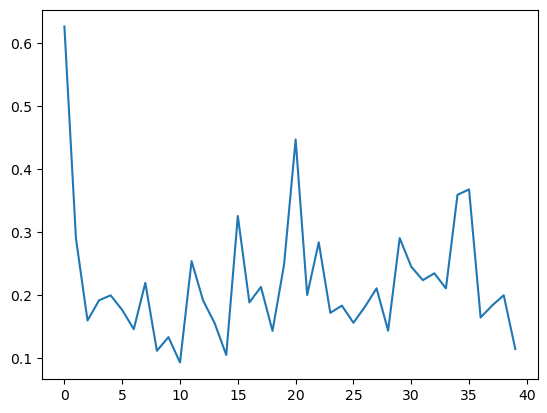

In [25]:
plt.plot(val_loss)

## 3. Test

#### pretraining plots

In [18]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/for_vm_ring_noisy_p0007_key2024/ring_noisy_p0007_biaxial_test_prob_FDM_pre_key2024.npy', 'rb') as f:
   [coord_2_strain_params, node_params, Lambda_params,mesh_points, elem_X, Force_x, Force_y, strains,
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist]=pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/for_vm_ring_noisy_p0007_key2024/ring_noisy_p0007_biaxial_test_prob_FDM_second_pretraining_key2024.pickle', 'rb') as f:
    [Lambda_params,val_loss, metrics]=pickle.load(f)

### stress plots for constant F

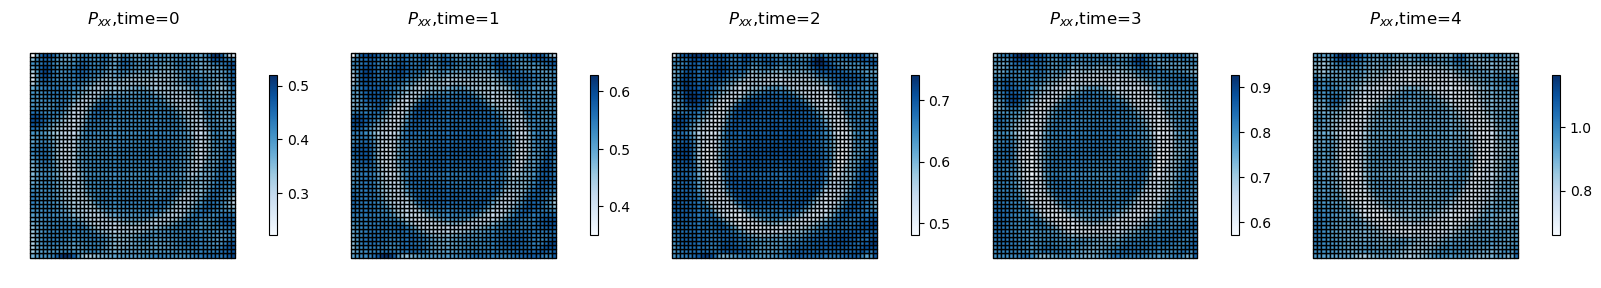

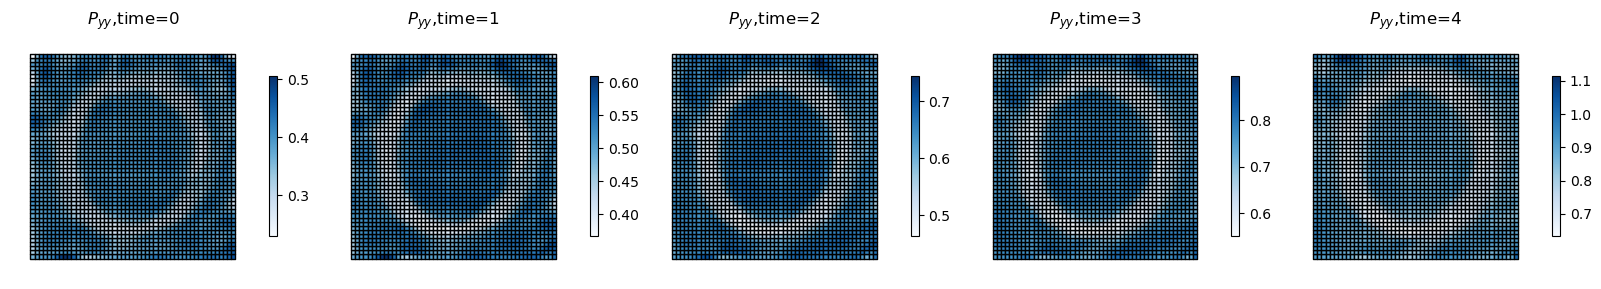

In [19]:
def get_P_pretraining_plot(F, X,Y,Lambda_params, model):
    F_xx=F[0,0]
    F_xy=F[0,1]
    F_yx=F[1,0]
    F_yy=F[1,1]
    #F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_pretraining_plot_vmap = vmap(get_P_pretraining_plot, in_axes=(0,0,0,None,None), out_axes=(0,0,0,0))
lmb_hist_plot = [1.05544, 1.07795, 1.10065, 1.12326, 1.14587]
t_hist = len(lmb_hist_plot )
n_plots = len(lmb_hist_plot)  
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols 
t_hist =np.arange(0, t_hist)
# c_range=np.ones((n_cols,2))
# c_range[:,[0]]=100000*c_range[:,[0]]
# c_range[:,[1]]=-100000*c_range[:,[1]]
ff_nn_ff = lambda x, params: ff_nn(x, params)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
id_for_range=0
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_x = axes_x.flatten()
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_y = axes_y.flatten()
for lam in lmb_hist_plot:
    ax_x = axes_x[id_for_range]
    ax_y = axes_y[id_for_range]
    uniform_F= lam *np.eye(2).reshape(1, 2, 2)
    uniform_F_batch= np.repeat(uniform_F, elem_X.shape[0], axis=0)
    P_xx, P_xy,P_yx,P_yy=get_P_pretraining_plot_vmap(uniform_F_batch, elem_X[:,0],elem_X[:,1],Lambda_params,NODE_w_unravel)
    title=fr'$P_{{xx}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_xx,title=title, ax=ax_x)
    title=fr'$P_{{yy}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_yy,title=title, ax=ax_y)
    id_for_range+=1

### stress plots with F obtained after NN interploation of displacements

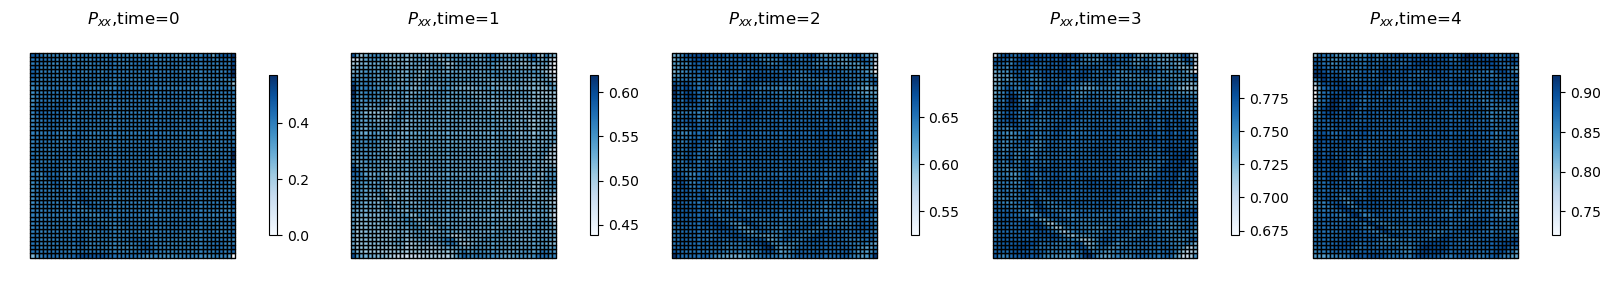

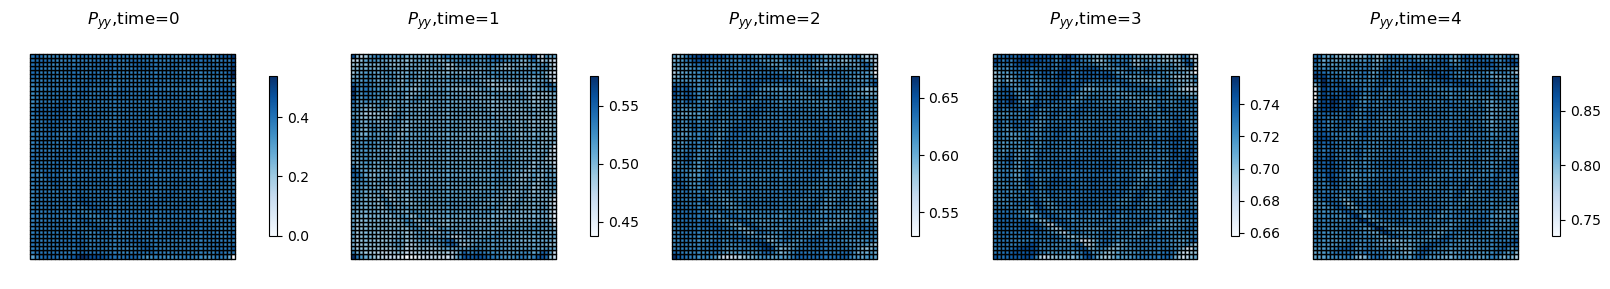

In [20]:
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)
id_for_range=0
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_x = axes_x.flatten()
axes_y = axes_y.flatten()
for idx, (t, F) in enumerate(zip(t_hist,F_hist_goh)):
    if id_for_range==n_cols:
        id_for_range=0
    t=t_hist[idx]
    Pxx,Pxy,Pyx,Pyy=get_P_pretraining_plot_vmap(F,elem_X[:,0],elem_X[:,1], Lambda_params,NODE_w_unravel)
    ax_x = axes_x[idx]
    ax_y = axes_y[idx]
    title=fr'$P_{{xx}}$,time={idx}'
    plotmesh(mesh.cells, mesh.points, Pxx,title=title, ax=ax_x)
    title=fr'$P_{{yy}}$,time={idx}'
    plotmesh(mesh.cells, mesh.points, Pyy,title=title, ax=ax_y)

In [21]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/for_vm_ring_noisy_p0007_key2024/ring_noisy_p0007_biaxial_test_prob_FDM_post_key2024.npy', 'rb') as f:
    [elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist]=pickle.load(f)

#### plots for the inverse problem

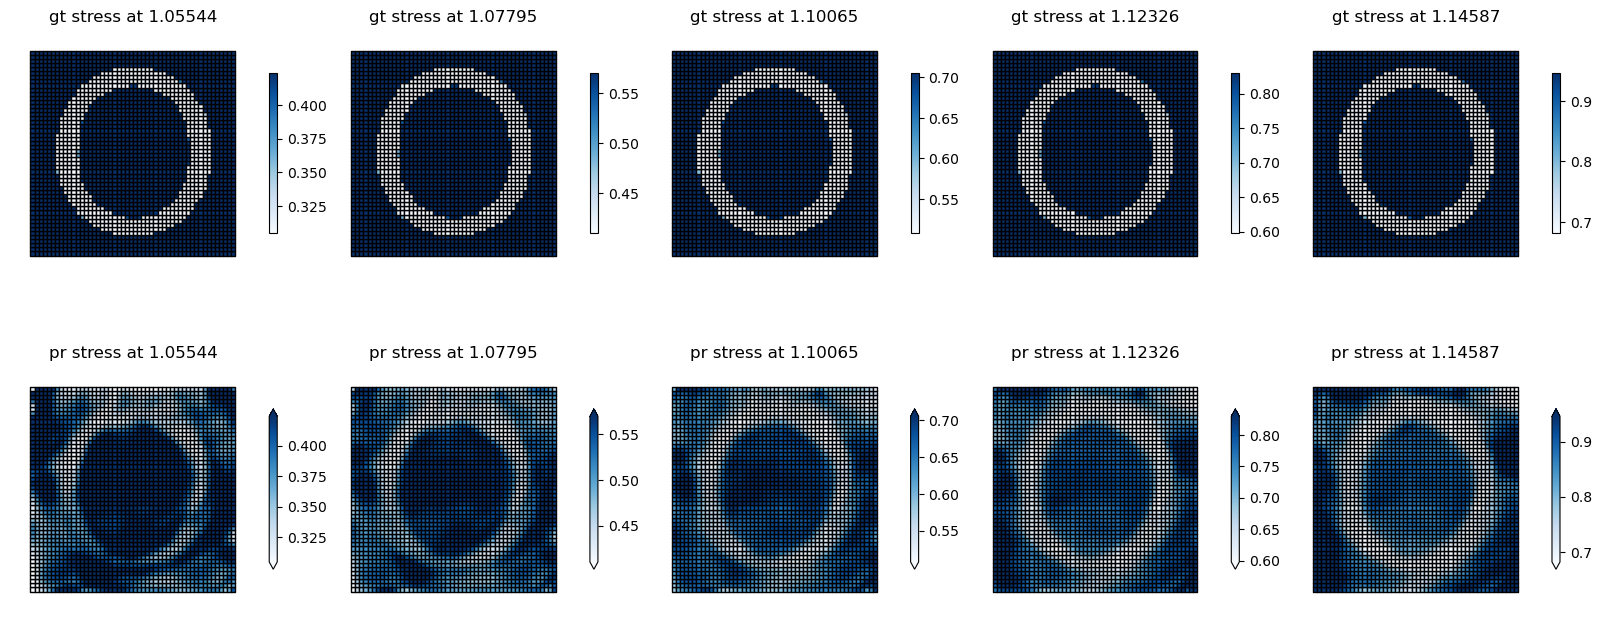

In [22]:
# Stiffness across the domain
fig, axes = plt.subplots(2,5,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 

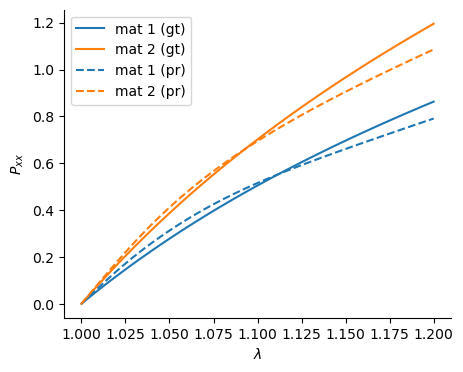

In [23]:
mat1_params = coords_2_params_gt([0.5,0.9])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.2)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.5, 0.9]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

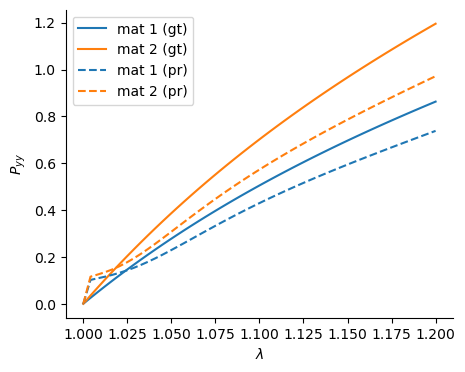

In [33]:
mat1_params = coords_2_params_gt([0.5,0.9])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.2)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.5, 0.9]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[1,1])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[1,1])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{yy}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)